# Furniture Sales Analysis

## KarirNex Data Analyst Bootcamp

### Objective

This notebook performs data cleaning, aggregation, exploratory data analysis, and visualization using the Furniture Sales dataset.

## Import Libraries

Import the required libraries for data cleaning, analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

Load the Furniture Sales dataset into a pandas DataFrame.

In [2]:
df=pd.read_csv('furniture_10k_FINAL.csv')

## Data Understanding

Inspect the dataset structure before cleaning.

In [3]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   sales_date        10000 non-null  object
 1   order_id          10000 non-null  object
 2   customer_name     10000 non-null  object
 3   product_name      10000 non-null  object
 4   category          10000 non-null  object
 5   price             10000 non-null  int64 
 6   quantity          10000 non-null  int64 
 7   discount          10000 non-null  object
 8   total             10000 non-null  int64 
 9   shipping_fee      10000 non-null  int64 
 10  total_sales       10000 non-null  int64 
 11  status            10000 non-null  object
 12  shipping_address  10000 non-null  object
dtypes: int64(5), object(8)
memory usage: 1015.8+ KB


,price,quantity,total,shipping_fee,total_sales
count,1.000000e+04,10000.000000,1.000000e+04,10000.000000,1.000000e+04
mean,2.646728e+06,1.994800,5.245963e+06,57016.000000,5.302979e+06
std,2.060574e+06,0.817949,4.844171e+06,4575.788214,4.844232e+06
min,6.500000e+05,1.000000,5.850000e+05,50000.000000,6.350000e+05
25%,1.250000e+06,1.000000,1.950000e+06,50000.000000,2.010000e+06
50%,1.850000e+06,2.000000,3.700000e+06,60000.000000,3.750000e+06
75%,3.250000e+06,3.000000,6.500000e+06,60000.000000,6.560000e+06
max,9.500000e+06,3.000000,2.850000e+07,60000.000000,2.856000e+07


## Data Cleaning

This section cleans the dataset by:

- converting data types
- removing duplicates
- handling missing values
- preparing data for analysis

In [4]:
df['sales_date'] = pd.to_datetime(df['sales_date'])
df['discount'] = df['discount'].astype(str).str.replace(',', '.', regex=False)
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['discount'] = df['discount'].fillna(0)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   sales_date        10000 non-null  datetime64[ns]
 1   order_id          10000 non-null  object        
 2   customer_name     10000 non-null  object        
 3   product_name      10000 non-null  object        
 4   category          10000 non-null  object        
 5   price             10000 non-null  int64         
 6   quantity          10000 non-null  int64         
 7   discount          10000 non-null  float64       
 8   total             10000 non-null  int64         
 9   shipping_fee      10000 non-null  int64         
 10  total_sales       10000 non-null  int64         
 11  status            10000 non-null  object        
 12  shipping_address  10000 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(5), object(6)
memory usage: 1015.8+ K

In [5]:
#Memeriksa dan menghapus duplikat data.
Jumlah_dup=df.duplicated().sum()
print ('baris duplikat mula-mula=',Jumlah_dup)

df=df.drop_duplicates()
Jumlah_dup=df.duplicated().sum()
print ('baris duplikat setelah dihapus=',Jumlah_dup)

baris duplikat mula-mula= 0
baris duplikat setelah dihapus= 0


In [6]:
# cek missing value
print(df.isnull().sum())
#isi kolom shipping_adress
df['shipping_address'].fillna('unknown',inplace=True)


sales_date          0
order_id            0
customer_name       0
product_name        0
category            0
price               0
quantity            0
discount            0
total               0
shipping_fee        0
total_sales         0
status              0
shipping_address    0
dtype: int64


In [7]:
df['city'] = df['shipping_address'].str.split(',').str[-1].str.strip()
df.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
0,2025-07-31,ORD00001,Customer_332,Kitchen Set,Dapur,9500000,1,0.0,9500000,60000,9560000,cancelled,"Kelurahan 120, Jakarta Pusat",Jakarta Pusat
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor",Bogor
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang",Tangerang


In [8]:
df_completed=df[df['status']=="completed"]
df_completed.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
1,2025-11-03,ORD00002,Customer_1150,Nakas,Kamar Tidur,1000000,2,0.0,2000000,60000,2060000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
2,2025-10-31,ORD00003,Customer_2122,Kursi Bar,Ruang Makan,1295000,2,0.0,2590000,60000,2650000,completed,"Kelurahan 108, Jakarta Pusat",Jakarta Pusat
3,2025-06-19,ORD00004,Customer_2636,Kasur,Kamar Tidur,5500000,3,0.0,16500000,50000,16550000,completed,"Kelurahan 36, Bogor",Bogor
4,2025-06-19,ORD00005,Customer_3379,Meja Makan,Ruang Makan,3200000,3,0.0,9600000,60000,9660000,completed,"Kelurahan 73, Tangerang",Tangerang
5,2025-01-11,ORD00006,Customer_793,Lemari Dapur,Dapur,1850000,1,0.0,1850000,60000,1910000,completed,"Kelurahan 176, Tangerang",Tangerang


## Sales Analysis by City

This section analyzes completed orders and identifies cities with the highest sales revenue.

In [9]:
top_sales_city=df_completed.groupby('city')['total_sales'].sum().sort_values(ascending=False)
top_sales_city.head(10)

,total_sales
city,
Jakarta Utara,5068862000
Jakarta Barat,5021356500
Jakarta Pusat,4996988000
Depok,4854175000
Bogor,4811721500
Jakarta Selatan,4764095500
Jakarta Timur,4666865000
Tangerang Selatan,4544961500
Tangerang,4415711500


## Advanced Analysis

This section analyzes promotional sales using discounted transactions and explores the relationship between product price, sales, and discount distribution.

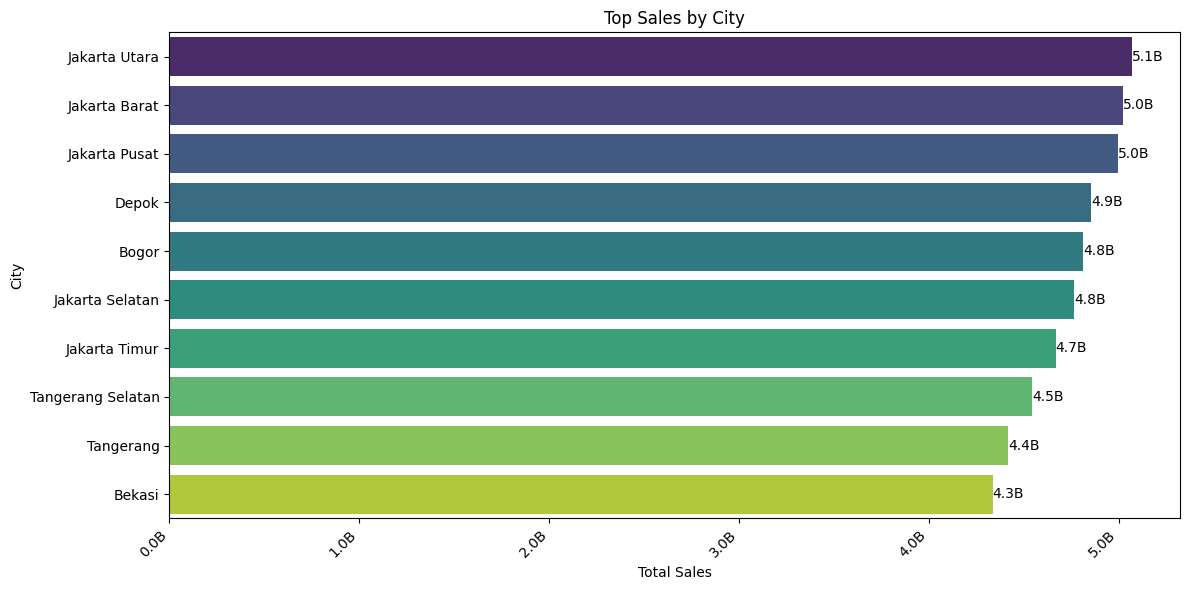

In [10]:
import matplotlib.ticker as ticker

plt.figure(figsize=(12, 6))
ax = sns.barplot(y=top_sales_city.index, x=top_sales_city.values, palette='viridis')
plt.title('Top Sales by City')
plt.xlabel('Total Sales')
plt.ylabel('City')

def format_billions(x, pos):
    return f'{x / 1e9:.1f}B'

ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_billions))

for index, value in enumerate(top_sales_city.values):
    ax.text(value, index, f'{value / 1e9:.1f}B', color='black', ha='left', va='center')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [11]:
df_discounted=df_completed[df_completed['discount']>0]
df_discounted.head()

,sales_date,order_id,customer_name,product_name,category,price,quantity,discount,total,shipping_fee,total_sales,status,shipping_address,city
9,2025-04-04,ORD00010,Customer_478,Lemari TV,Ruang Tamu,2300000,1,0.1,2070000,50000,2120000,completed,"Kelurahan 94, Depok",Depok
27,2025-12-12,ORD00028,Customer_2282,Rak Sepatu,Penyimpanan,650000,2,0.1,1170000,60000,1230000,completed,"Kelurahan 44, Jakarta Selatan",Jakarta Selatan
35,2025-01-01,ORD00036,Customer_1985,Lemari Baju,Kamar Tidur,3500000,2,0.1,6300000,60000,6360000,completed,"Kelurahan 90, Tangerang Selatan",Tangerang Selatan
42,2025-10-10,ORD00043,Customer_59,Lemari Sliding,Kamar Tidur,4750000,3,0.1,12825000,60000,12885000,completed,"Kelurahan 9, Jakarta Pusat",Jakarta Pusat
44,2025-10-10,ORD00045,Customer_3025,Lemari Laci,Kamar Tidur,1950000,3,0.1,5265000,60000,5325000,completed,"Kelurahan 102, Jakarta Selatan",Jakarta Selatan


In [12]:
product_name_by_total_sales=df_discounted.groupby('product_name')['total_sales'].sum().sort_values(ascending=False)
product_name_by_total_sales.head(10)


,total_sales
product_name,
Kitchen Set,214530000
Kasur,139400000
Lemari Baju,114480000
Lemari Sliding,107435000
Bufet,106270000
Sofa,101870000
Lemari TV,79670000
Lemari Dapur,67880000
Lemari Sudut,62615000


In [13]:
product_name_by_avg_discount=df_discounted.groupby('product_name')['discount'].mean().sort_values(ascending=False)
product_name_by_avg_discount.head(10)


,discount
product_name,
Bufet,0.1
Kasur,0.1
Kitchen Set,0.1
Kursi,0.1
Kursi Bar,0.1
Lemari Baju,0.1
Lemari Dapur,0.1
Lemari Laci,0.1
Lemari Sliding,0.1


In [14]:
Product_name_by_avg_quantity=df_discounted.groupby('product_name')['quantity'].mean().sort_values(ascending=False)
Product_name_by_avg_quantity.head(10)

,quantity
product_name,
Lemari Sliding,2.500000
Kursi Bar,2.461538
Sofa,2.272727
Rak Buku,2.272727
Rak Sepatu,2.150000
Rak Meja,2.142857
Nakas,2.133333
Kursi,2.125000
Bufet,2.117647


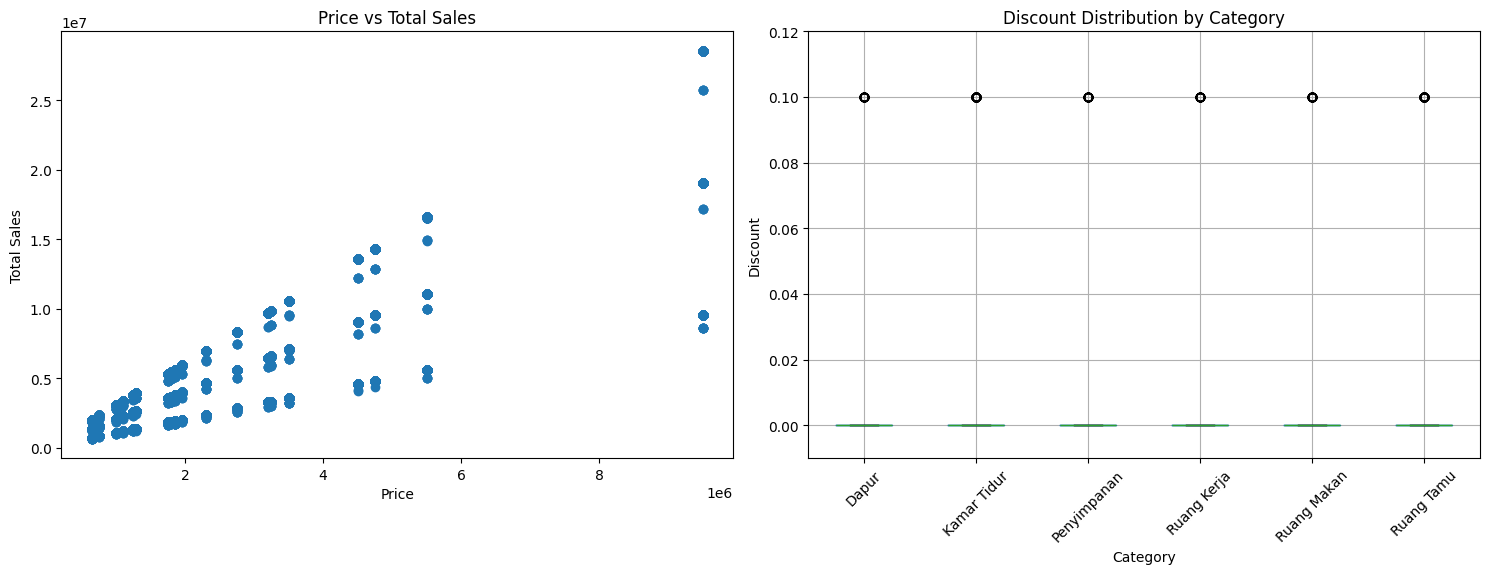

In [20]:

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

ax[0].scatter(df_completed['price'], df_completed['total_sales'])
ax[0].set_title('Price vs Total Sales')
ax[0].set_xlabel('Price')
ax[0].set_ylabel('Total Sales')

df_completed.boxplot(
    column='discount',
    by='category',
    ax=ax[1]
)

ax[1].set_ylim(-0.01, 0.12)
ax[1].set_title('Discount Distribution by Category')
ax[1].set_xlabel('Category')
ax[1].set_ylabel('Discount')

plt.suptitle('')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [16]:
print(df_completed['discount'].value_counts())

discount
0.0    8679
0.1     293
Name: count, dtype: int64


# Business Insights

### Insight 1
Jakarta Selatan generated the highest completed sales revenue, indicating strong customer demand in this region.

### Insight 2
Most completed transactions did not use discounts, showing that products are generally purchased at full price.

### Insight 3
Products with higher prices tend to generate higher total sales, although several high-priced products still record relatively low sales.

## Business Recommendations

- Focus marketing campaigns on high-performing cities.
- Evaluate the effectiveness of discount promotions since only a small portion of completed transactions use discounts.
- Increase promotional efforts for products with lower sales performance.